# T3 — Barrier boost experiments: does it help, and which recommender works best?

**Plant design (Sheet1):** barrier boost is recommended from MB3 (bottom temperature), draw and cullet.

**Questions**
1. **Does barrier boost help?** Checked three ways: for MB3, for the gas model, and for SFC.
2. **Which MB3 response model** should the controller use? Tested with and without gas history and the crown thermocouple.
3. **Which recommendation policy** holds MB3 best with the least boost?
   - P1: copy the operators with a regression (the plant's design)
   - P4: the same copy with LightGBM
   - P2: integral controller on MB3
   - P3: hybrid of a feedforward term and the integral controller

**How policies are compared:** a closed-loop hourly replay on two folds, Mar–May 2026 and Jun–Aug 2026. MB3 is re-simulated as the actual MB3 plus the effect of our boost changes, using the measured step response. The MB3 target is the historical median.

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import warnings, lightgbm as lgb
import recommender as rc
warnings.simplefilter('ignore')
h = pd.read_parquet(dp.PROCESSED / 'hourly_clean.parquet'); q = pd.read_parquet(dp.PROCESSED / 'ar_15min_clean.parquet')
d = pd.read_parquet(dp.PROCESSED / 'daily_clean.parquet')
FOLDS = {'Mar-May 2026': ('2026-03-01', '2026-05-31', '2026-01-15'), 'Jun-Aug 2026': ('2026-06-01', '2026-08-31', '2026-04-17')}
lim = rc.historical_limits(q, h); LO, HI = lim.loc['bb_kwh (per hour)', ['P1', 'P99']]
TGT = h.mb3_temp.median(); P5, P95 = h.mb3_temp.quantile([0.05, 0.95])
print('MB3 target (historical median) %.2f °C | historical P5-P95 %.2f-%.2f | boost limits %.0f-%.0f kWh/h' % (TGT, P5, P95, LO, HI))

MB3 target (historical median) 1320.25 °C | historical P5-P95 1317.60-1323.91 | boost limits 114-610 kWh/h


## 1. Does barrier boost help?

In [2]:
u = rc.add_gcal_columns(d[d.usable]); u['age_m'] = (u.index - pd.Timestamp('2025-09-01')).days / 30.44
off = (u.opt_temp.where(u.opt_day_ok) - u.crown_tc).rolling(30, min_periods=5).median().ffill().bfill()
u['opt_f_prev'] = u.opt_temp.where(u.opt_day_ok).fillna(u.crown_tc + off).shift(1)
gm = smf.ols('gas_g ~ draw_t + bb_g + mb_g + age_m + opt_f_prev', u).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
fe = smf.ols('gas_g ~ draw_t + bb_g + mb_g + C(mon)', u.assign(mon=u.index.to_period('M').astype(str))).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
step = rc.boost_step_response(h, 12)
pd.DataFrame({'question': ['Does boost move MB3?', 'Does the gas model need boost as an input?', 'Does more boost lower total energy (SFC)?'],
              'evidence': ['+%.2f °C MB3 per +100 kWh/h (steady state, 12 h)' % (step.iloc[-1]*100),
                           'T1: removing boost raises the error by about 27%% (pinball 0.344 -> 0.437)',
                           '1 Gcal boost replaces %.2f Gcal gas (final gas model) / %.2f (month fixed effects) -> net %+.2f / %+.2f Gcal' % (
                               -gm.params.bb_g, -fe.params.bb_g, 1 + gm.params.bb_g, 1 + fe.params.bb_g)],
              'answer': ['YES: it is the handle for MB3', 'YES: keep it as an input', 'NO: less boost (with MB3 held) saves energy']})

,question,evidence,answer
0,Does boost move MB3?,"+1.94 °C MB3 per +100 kWh/h (steady state, 12 h)",YES: it is the handle for MB3
1,Does the gas model need boost as an input?,T1: removing boost raises the error by about 2...,YES: keep it as an input
2,Does more boost lower total energy (SFC)?,1 Gcal boost replaces 0.70 Gcal gas (final gas...,NO: less boost (with MB3 held) saves energy


**Reading 1.**
- Barrier boost **helps for temperature control** (it is the handle for MB3), and the gas model **needs it as an input**.
- But it **doesn't save energy**: each Gcal of boost replaces only 0.7–0.8 Gcal of gas.
- So the boost recommender should give the **minimum boost that holds MB3 at its target**, not more.

## 2. MB3 response model: which inputs?
The model predicts the MB3 change over the next 3 hours from the last 0–12 hours of changes in boost, gas and (optionally) the crown thermocouple. It is trained on data before each fold and tested on the fold.

Optical can't be tested here: its hourly time stamps are unreliable in most 2026 months (nb02).

In [3]:
x = h[['mb3_temp', 'bb_kwh', 'gas_kcal', 'crown_tc', 'draw_t']].asfreq('h')
df = pd.DataFrame({'y': x.mb3_temp.shift(-3) - x.mb3_temp}, index=x.index)
for k in range(13):
    df[f'b{k}'] = x.bb_kwh.diff().shift(k); df[f'g{k}'] = (x.gas_kcal/1e6).diff().shift(k); df[f't{k}'] = x.crown_tc.diff().shift(k)
df['mb3_dev'] = x.mb3_temp - x.mb3_temp.rolling(24).mean(); df['draw'] = x.draw_t
Bv, Gv, Tv = [' + '.join(f'{c}{k}' for k in range(13)) for c in 'bgt']
VARS = {'boost history': Bv, 'boost + gas history': Bv + ' + ' + Gv, 'boost + gas + crown TC history': Bv + ' + ' + Gv + ' + ' + Tv,
        'boost + gas + MB3 level': Bv + ' + ' + Gv + ' + mb3_dev', 'boost + gas + MB3 level + draw': Bv + ' + ' + Gv + ' + mb3_dev + draw'}
rows = []
for fold, (a, b, _) in FOLDS.items():
    tr = df[:pd.Timestamp(a) - pd.Timedelta(hours=1)].dropna(); te = df[a:b].dropna()
    for name, f in VARS.items():
        m = smf.ols('y ~ ' + f, tr).fit(); p = m.predict(te)
        rows.append(dict(fold=fold, model=name, oos_R2=1 - ((te.y - p)**2).sum() / ((te.y - te.y.mean())**2).sum()))
M = pd.DataFrame(rows)
display(M.pivot_table(index='model', columns='fold', values='oos_R2').round(3))
# Steady-state boost gain (what the controller uses): 1-hour MB3 change on boost/gas (and optionally crown TC) history
df1 = df.copy(); df1['y1'] = x.mb3_temp.diff()
def gain(f):
    m = smf.ols('y1 ~ ' + f, df1.dropna()).fit()
    return float(pd.Series([m.params[f'b{k}'] for k in range(13)]).cumsum().clip(lower=0).cummax().iloc[-1] * 100)
pd.DataFrame({'MB3 gain after 12 h (°C per +100 kWh/h)': [gain(Bv + ' + ' + Gv), gain(Bv + ' + ' + Gv + ' + ' + Tv)]},
             index=['boost + gas history', 'boost + gas + crown TC history']).round(2)

fold,Jun-Aug 2026,Mar-May 2026
model,,
boost + gas + MB3 level,0.539,0.539
boost + gas + MB3 level + draw,0.539,0.537
boost + gas + crown TC history,0.547,0.556
boost + gas history,0.534,0.540
boost history,0.474,0.532


,MB3 gain after 12 h (°C per +100 kWh/h)
boost + gas history,1.94
boost + gas + crown TC history,1.92


**Reading 2.**
- Boost and gas history explain over half of the next-3-hour MB3 movement out of sample.
- Adding the **crown thermocouple** history improves the prediction only slightly (about +0.015 R²), and it is not something the operator can set.
- The **steady-state boost gain** the controller relies on (second table) is about the same with or without the crown thermocouple, so the controller gain is robust.
- **Choice:** the boost + gas step response for the controller. The crown temperature is not needed for Model 2.

## 3. Which recommendation policy works best? (closed-loop replay)

In [4]:
G = step.iloc[-1]
rowsP, sims = [], {}
for fold, (a, b, tra) in FOLDS.items():
    hh = h[a:b + ' 23:00']
    tr = h[tra:pd.Timestamp(a) - pd.Timedelta(hours=1)].dropna(subset=['bb_kwh', 'mb3_temp', 'draw_t', 'cullet_pct'])
    ols = smf.ols('bb_kwh ~ mb3_temp + draw_t + cullet_pct', tr).fit()
    X = ['mb3_temp', 'draw_t', 'cullet_pct']
    gbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=7, min_child_samples=30, verbose=-1).fit(tr[X], tr.bb_kwh)
    state = {'I': 0.0}
    pols = {
        'P1 copy operators (OLS: MB3, draw, cullet)': lambda prev, m, r: np.clip(ols.params.Intercept + ols.params.mb3_temp*m + ols.params.draw_t*r.draw_t + ols.params.cullet_pct*r.cullet_pct, LO, HI),
        'P4 copy operators (LightGBM)': lambda prev, m, r: np.clip(gbm.predict(pd.DataFrame([[m, r.draw_t, r.cullet_pct]], columns=X))[0], LO, HI),
        'P2 integral controller on MB3': lambda prev, m, r: np.clip(prev + 0.1*(TGT - m)/G, LO, HI)}
    def hybrid(prev, m, r):
        ff = ols.params.Intercept + ols.params.mb3_temp*TGT + ols.params.draw_t*r.draw_t + ols.params.cullet_pct*r.cullet_pct
        state['I'] += 0.1*(TGT - m)/G
        return np.clip(ff + state['I'], LO, HI)
    pols['P3 hybrid (feedforward + integral)'] = hybrid
    print(fold, '| P1 regression MB3 coefficient: %.2f kWh/h per °C' % ols.params.mb3_temp)
    for name, pol in pols.items():
        state['I'] = 0.0
        r = rc.simulate_policy(hh, step, pol); sims[(fold, name)] = r
        rowsP.append(dict(fold=fold, policy=name, mb3_abs_error=(r.mb3_sim - TGT).abs().mean(), hours_in_P5_P95_pct=100*r.mb3_sim.between(P5, P95).mean(),
                          boost_rec=r.bb_rec.mean(), boost_actual=r.bb_kwh.mean(), hourly_move=r.bb_rec.diff().abs().mean(),
                          net_energy_Gcal_day=(r.bb_rec - r.bb_kwh).mean()*24*860/1e6*(1 + gm.params.bb_g)))
P = pd.DataFrame(rowsP)
P.pivot_table(index='policy', columns='fold', values=['mb3_abs_error', 'boost_rec', 'hourly_move', 'net_energy_Gcal_day']).round(2)

Mar-May 2026 | P1 regression MB3 coefficient: -0.56 kWh/h per °C


Jun-Aug 2026 | P1 regression MB3 coefficient: -21.81 kWh/h per °C


boost_rec               hourly_move              mb3_abs_error              net_energy_Gcal_day             
fold                                       Jun-Aug 2026 Mar-May 2026 Jun-Aug 2026 Mar-May 2026  Jun-Aug 2026 Mar-May 2026        Jun-Aug 2026 Mar-May 2026
policy                                                                                                                                                    
P1 copy operators (OLS: MB3, draw, cullet)       320.68       369.03        11.05         1.62          1.42         1.09               -0.16        -0.01
P2 integral controller on MB3                    267.62       382.38         5.43         5.25          1.09         1.05               -0.49         0.07
P3 hybrid (feedforward + integral)               265.89       382.79         6.23         6.63          1.12         1.10               -0.50         0.07
P4 copy operators (LightGBM)                     323.87       368.35        13.63        12.81          1.39         1.08               -0.14        -0.02

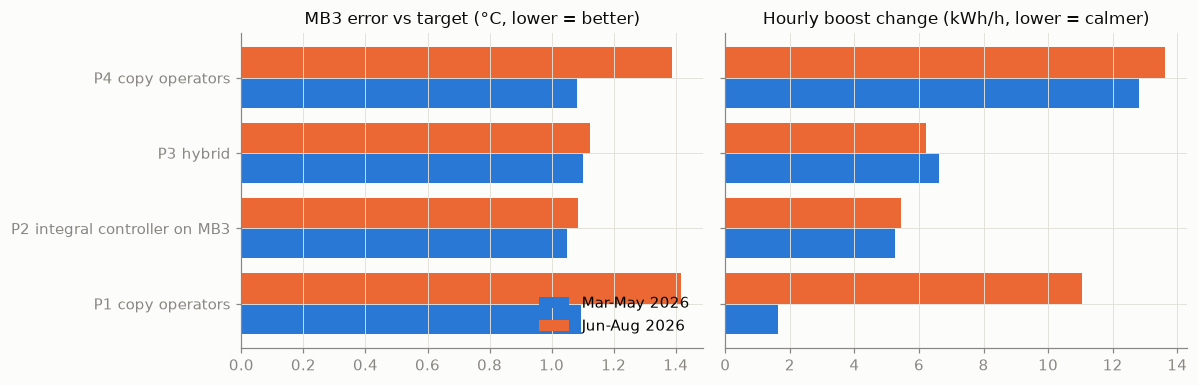

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for i, metric, ttl in [(0, 'mb3_abs_error', 'MB3 error vs target (°C, lower = better)'), (1, 'hourly_move', 'Hourly boost change (kWh/h, lower = calmer)')]:
    pv = P.pivot_table(index='policy', columns='fold', values=metric)
    yy = np.arange(len(pv))
    ax[i].barh(yy - 0.2, pv['Mar-May 2026'], height=0.4, color=BLUE, label='Mar-May 2026')
    ax[i].barh(yy + 0.2, pv['Jun-Aug 2026'], height=0.4, color=ORANGE, label='Jun-Aug 2026')
    ax[i].set_yticks(yy); ax[i].set_yticklabels([s.split(' (')[0] for s in pv.index] if i == 0 else [''] * len(pv)); ax[i].set_title(ttl)
ax[0].legend(loc='lower right'); plt.tight_layout(); plt.show()

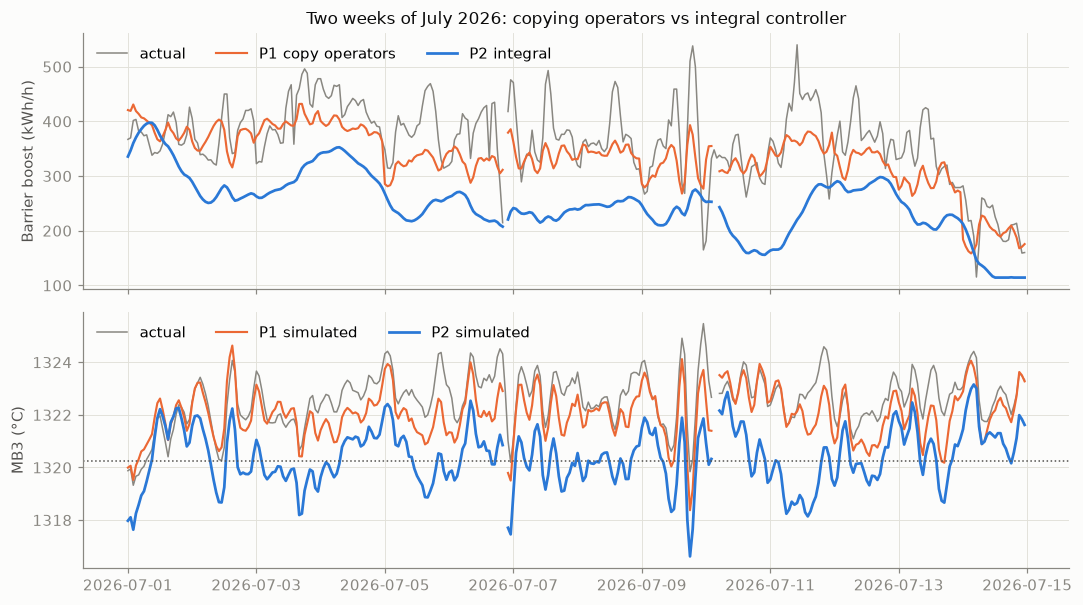

In [6]:
r = sims[('Jun-Aug 2026', 'P2 integral controller on MB3')].loc['2026-07-01':'2026-07-14']
r1 = sims[('Jun-Aug 2026', 'P1 copy operators (OLS: MB3, draw, cullet)')].loc['2026-07-01':'2026-07-14']
fig, ax = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
ax[0].plot(r.index, r.bb_kwh, color=MUTED, lw=1, label='actual'); ax[0].plot(r1.index, r1.bb_rec, color=ORANGE, lw=1.4, label='P1 copy operators')
ax[0].plot(r.index, r.bb_rec, color=BLUE, lw=1.8, label='P2 integral'); ax[0].set_ylabel('Barrier boost (kWh/h)'); ax[0].legend(loc='upper left', ncol=3)
ax[1].plot(r.index, r.mb3_temp, color=MUTED, lw=1, label='actual'); ax[1].plot(r1.index, r1.mb3_sim, color=ORANGE, lw=1.4, label='P1 simulated')
ax[1].plot(r.index, r.mb3_sim, color=BLUE, lw=1.8, label='P2 simulated'); ax[1].axhline(TGT, color=INK2, lw=1, ls=':')
ax[1].set_ylabel('MB3 (°C)'); ax[1].legend(loc='upper left', ncol=3)
ax[0].set_title('Two weeks of July 2026: copying operators vs integral controller'); plt.tight_layout(); plt.show()

**Reading 3.**
- **P1 copy operators (the plant's original design):**
  - its MB3 coefficient changes hugely between training windows (printed above), so it isn't a stable relationship
  - it reproduces the operators' habit, including holding MB3 above target in Jun–Aug
  - so it tracks worse and saves little
- **P4 LightGBM copy:** the same idea, but with jumpy boost moves.
- **P2 integral controller:** the best MB3 tracking in both folds, with small, calm hourly moves. In Jun–Aug it uses clearly less boost, because MB3 was above target. In Mar–May MB3 was below target, so it uses slightly *more* boost. That is correct: it holds the temperature, not a boost level.
- **P3 hybrid:** about the same as P2, but more complex, and it inherits P1's unstable feedforward term.

## Decision for Model 2 (barrier boost)
| Choice | Decision | Why |
|---|---|---|
| Role of barrier boost | **The MB3 handle. Use the minimum that holds the target** | It controls MB3 but doesn't save energy (section 1) |
| Response model | Distributed lag of MB3 on boost + gas history (0–12 h). Step response ≈ +1.9 °C per +100 kWh/h | Robust gain; the crown thermocouple adds little (section 2) |
| Policy | **P2 integral controller:** `bb(t) = bb(t-1) + 0.1 × (MB3_target − MB3) / gain`, clipped to historical P1–P99 | Best tracking, calm moves, stable (section 3) |
| Draw and cullet | Not needed in the policy. The feedback on MB3 automatically absorbs their effect | P1/P3 feedforward on draw and cullet was unstable |
| Crown temperature | Not used | Not controllable by boost; little added information |

In [7]:
P.to_csv(dp.PROCESSED / 'training_boost_policies.csv', index=False); print('saved training_boost_policies.csv')

saved training_boost_policies.csv
